# Baseline Spleen Segmentation with UniverSeg
# This notebook loads processed MSD Task09 Spleen 2D CT slices, sets up a 2-shot support set,
# runs zero-shot in-context evaluation with UniverSeg, and plots comparisons.


In [1]:
import sys
import os
import torch
import numpy as np
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

# Add external/universeg to sys.path
sys.path.append(os.path.abspath('../external/universeg'))
from universeg import universeg


In [2]:
# 1. Load Processed Dataset
data_dir = '../data/processed'
images = np.load(os.path.join(data_dir, 'spleen_images.npy'))
masks = np.load(os.path.join(data_dir, 'spleen_masks.npy'))

print(f'Loaded spleen images shape: {images.shape}, dtype: {images.dtype}')
print(f'Loaded spleen masks shape:  {masks.shape}, dtype: {masks.dtype}')


Loaded spleen images shape: (305, 512, 512), dtype: float32
Loaded spleen masks shape:  (305, 512, 512), dtype: uint8


In [3]:
# 2. Pick Support and Test Sets
np.random.seed(42)
torch.manual_seed(42)

all_indices = np.arange(len(images))
support_indices = np.random.choice(all_indices, size=2, replace=False)
remaining_indices = np.setdiff1d(all_indices, support_indices)
test_indices = np.random.choice(remaining_indices, size=5, replace=False)

print(f'Support Set Slices (2): {support_indices}')
print(f'Test Set Slices (5):    {test_indices}')


Support Set Slices (2): [180 154]
Test Set Slices (5):    [233 303 104 294 160]


In [4]:
# 3. Preprocess and Tensorize (Resize to 128x128 for UniverSeg)
def preprocess_tensor(img, mask):
    t_img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
    t_msk = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0).unsqueeze(0)
    t_img_res = TF.resize(t_img, [128, 128], antialias=True)
    t_msk_res = TF.resize(t_msk, [128, 128], antialias=False)
    return t_img_res.squeeze(0), t_msk_res.squeeze(0)

supp_imgs, supp_msks = [], []
for idx in support_indices:
    si, sm = preprocess_tensor(images[idx], masks[idx])
    supp_imgs.append(si)
    supp_msks.append(sm)

support_images_t = torch.stack(supp_imgs, dim=0).unsqueeze(0) # (1, 2, 1, 128, 128)
support_masks_t = torch.stack(supp_msks, dim=0).unsqueeze(0)  # (1, 2, 1, 128, 128)


In [5]:
# 4. Instantiate Pretrained UniverSeg Model
model = universeg(pretrained=True).eval()
print('Loaded pretrained UniverSeg model successfully.')


Loaded pretrained UniverSeg model successfully.


In [6]:
# 5. Run In-Context Inference & Compute Dice Score
def dice_score(pred, target, eps=1e-6):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return ((2.0 * intersection + eps) / (union + eps)).item()

results = []
for i, idx in enumerate(test_indices):
    ti, tm = preprocess_tensor(images[idx], masks[idx])
    target_img_t = ti.unsqueeze(0) # (1, 1, 128, 128)
    
    with torch.no_grad():
        logits = model(target_img_t, support_images_t, support_masks_t)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
    
    score = dice_score(preds[0, 0], tm[0])
    results.append({
        'test_idx': idx,
        'ct_img': images[idx],
        'gt_mask': tm[0].cpu().numpy(),
        'pred_mask': preds[0, 0].cpu().numpy(),
        'dice': score
    })
    print(f'Test Slice {i+1} (idx {idx}): Dice Score = {score:.4f}')

avg_dice = float(np.mean([r['dice'] for r in results]))
print(f'Overall Average Dice Score (5 test slices): {avg_dice:.4f}')


Test Slice 1 (idx 233): Dice Score = 0.7834


Test Slice 2 (idx 303): Dice Score = 0.6712
Test Slice 3 (idx 104): Dice Score = 0.1802
Test Slice 4 (idx 294): Dice Score = 0.5319


Test Slice 5 (idx 160): Dice Score = 0.6560
Overall Average Dice Score (5 test slices): 0.5645


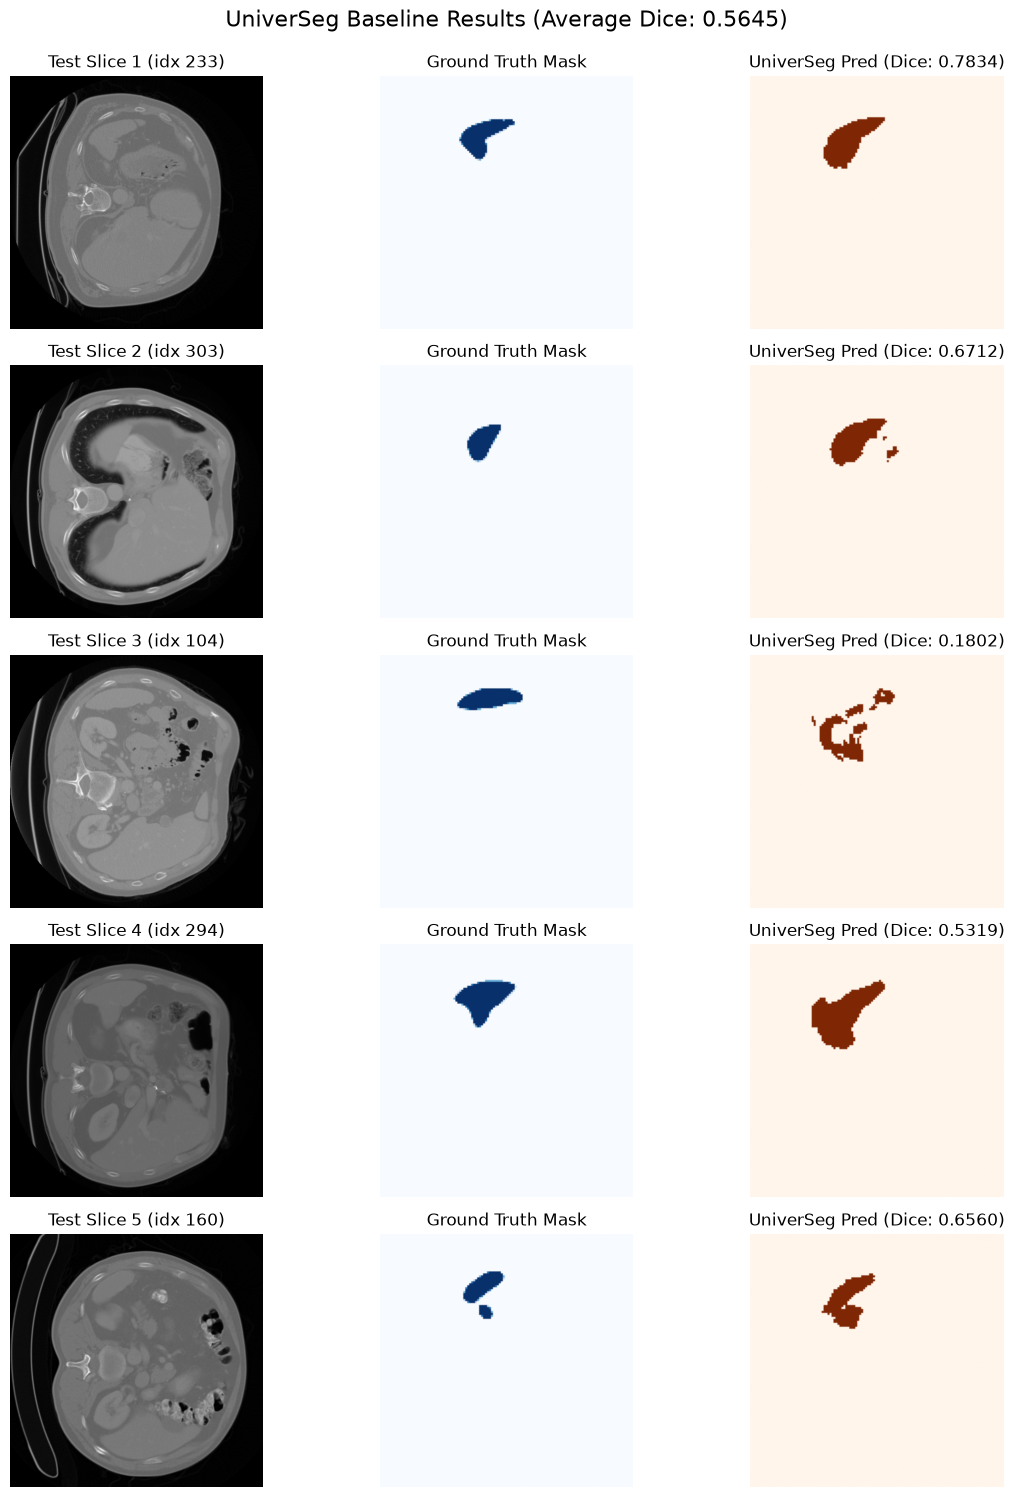

In [7]:
# 6. Display Visual Comparisons (CT Slice, Ground Truth Mask, Predicted Mask)
fig, axes = plt.subplots(len(results), 3, figsize=(12, 3 * len(results)))
plt.suptitle(f'UniverSeg Baseline Results (Average Dice: {avg_dice:.4f})', fontsize=16, y=0.995)

for i, res in enumerate(results):
    t_idx = res['test_idx']
    d_score = res['dice']
    # CT Slice
    axes[i, 0].imshow(res['ct_img'], cmap='gray')
    axes[i, 0].set_title(f'Test Slice {i+1} (idx {t_idx})')
    axes[i, 0].axis('off')
    
    # Ground Truth Mask
    axes[i, 1].imshow(res['gt_mask'], cmap='Blues', vmin=0, vmax=1)
    axes[i, 1].set_title('Ground Truth Mask')
    axes[i, 1].axis('off')
    
    # Predicted Mask
    axes[i, 2].imshow(res['pred_mask'], cmap='Oranges', vmin=0, vmax=1)
    axes[i, 2].set_title(f'UniverSeg Pred (Dice: {d_score:.4f})')
    axes[i, 2].axis('off')

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/baseline_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
